### NLP - (Natural Language Processing)

- NLP is Most Commanly stands For Natural Language Processing,   A branch of artificial intelligence that helps computers to Read,   Hear, Speak, And Understand Human text And Speech

### RoadMap:
- 1. Text Preprocessing:  
      - Tokenaization
      - Lemmatization
      - stemming
      - stop word
- 2. Text Preprocessing:
      - convert Word to vector
      - Bagword
      - unigram 
      - IFIDF
      - Biogram
- 3. Text Preprocessing:
      - Word to Vector
      - Avg word to vector
- 4. RNN,LSTM RNN, GRU RNN:
      - Deep Learning
- 5. Text Preprocessing:
      - Word Embedding
- 6. BERT                             

### Tokenization:
 - Tokenization in Natural Language Processing (NLP) is the process of breaking down text into smaller units called tokens.   
 These tokens can be words, subwords, characters, or sentences, depending on the application.

### Sentence Tokenization

In [42]:
import nltk
#Paragraphs To sentence
from nltk.tokenize import sent_tokenize

text = """Apple is looking at buying a startup.
Please do watch Entire Course! to become an expert in NLP
"""
sent_tokenize(text)


['Apple is looking at buying a startup.',
 'Please do watch Entire Course!',
 'to become an expert in NLP']

### Word Tokenization

In [43]:
#Tokenization
# Paragraph --> Word
# Sentence -->  Word

from nltk.tokenize import word_tokenize
word_tokenize(text)

['Apple',
 'is',
 'looking',
 'at',
 'buying',
 'a',
 'startup',
 '.',
 'Please',
 'do',
 'watch',
 'Entire',
 'Course',
 '!',
 'to',
 'become',
 'an',
 'expert',
 'in',
 'NLP']

### Stemming

- Stemming is a text preprocessing technique in Natural Language Processing (NLP) that reduces a word to its root form (stem) by removing prefixes or suffixes
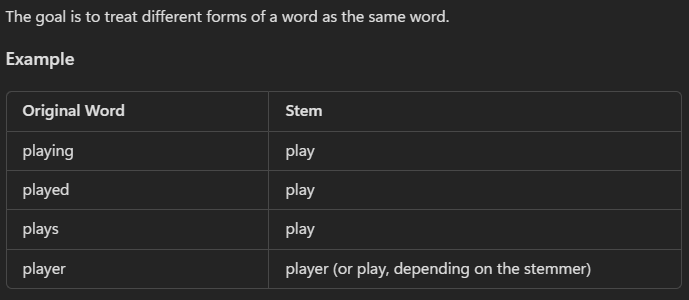

### Types:
- Porter Stemmer
- Snowball Stemmer
- Lancaster Stemmer

#### PorterStemmer

In [44]:
from nltk.stem import PorterStemmer

stem = PorterStemmer()

Words = ["Eating",'Playing','Runned','Walked','Writing','Reading','Running','history']

for word in Words:
    print(word+"---->"+stem.stem(word))

Eating---->eat
Playing---->play
Runned---->run
Walked---->walk
Writing---->write
Reading---->read
Running---->run
history---->histori


### RegexpStemmer

In [45]:
from nltk.stem import RegexpStemmer

reg = RegexpStemmer('ing$|s$|e$|able$',min=4)
reg.stem('Playing')

'Play'

### Snaowball Stemmer:
- Improved version of Porter Stemmer.

In [46]:
from nltk.stem import SnowballStemmer

snow = SnowballStemmer('english')

for word in Words:
    print(word+"----->" + snow.stem(word))

Eating----->eat
Playing----->play
Runned----->run
Walked----->walk
Writing----->write
Reading----->read
Running----->run
history----->histori


### Porter stemming vs Snowball Stemming

In [47]:
stem.stem('Fairly'),stem.stem('Sportingly')

('fairli', 'sportingli')

In [48]:
snow.stem('Fairly'),snow.stem('Sportingly')

('fair', 'sport')

### Limitaization
- the output we will get after lemmatization is called 'lemma' which is a root word rather than the root stem.  
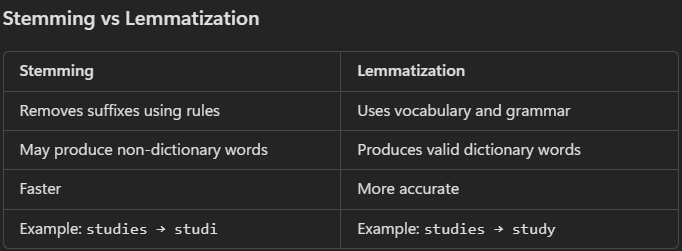

In [49]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
'''
POS:
Noun-n
Verb-v
adjactive-a
adverb-r
'''
lemmatizer.lemmatize("going",pos='v')


'go'

In [50]:
words=['eating','eats','eaten','writing','writes','programming','programs','history','finally','finalized','fairly','sportingly']

for word in words:
    print(word+"---->"+lemmatizer.lemmatize(word,pos='v'))#deafult the pos will be noun

eating---->eat
eats---->eat
eaten---->eat
writing---->write
writes---->write
programming---->program
programs---->program
history---->history
finally---->finally
finalized---->finalize
fairly---->fairly
sportingly---->sportingly


### StopWords
- Stop words are commonly used words in a language that are often removed during text preprocessing because they carry little meaningful information for many NLP tasks.
- Example: is,in, a, an ,the,as,are,etc....


In [53]:
paragraph = '''The students are learning Natural Language Processing in the computer laboratory. They are using different techniques to analyze text data and extract meaningful information. The instructors are explaining how words like "the", "is", "are", "and", and "of" are commonly used in sentences but often do not contribute much to the overall meaning. Therefore, these words can be removed during the preprocessing stage to improve the performance of NLP models.'''


from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
sentence = nltk.sent_tokenize(paragraph)
type(sentence)

list

### Using Stem i have done the stopwords

In [40]:
#Apply stopwords and filter and then apply stemming
custom_stopwords = {
'a', 'an', 'the', 'is', 'am', 'are', 'was', 'were',
'in', 'on', 'at', 'of', 'to', 'for', 'and', 'or',
'but', 'with', 'by'
}
for i in range(len(sentence)):
    words = nltk.word_tokenize(sentence[i])
    words =[stem.stem(word) for word in words if word.lower() not in custom_stopwords]
    sentence[i] =' '.join(words) #converting all the words into sentence
sentence

['student learn natur languag process comput laboratori .',
 'they use differ techniqu analyz text data extract meaning inform .',
 "instructor explain how word like `` '' , `` '' , `` '' , `` '' , `` '' commonli use sentenc often do not contribut much overal mean .",
 'therefor , these word can be remov dure preprocess stage improv perform nlp model .']

### using Snowball i have done the stopword

In [55]:
from nltk.stem import SnowballStemmer
snow = SnowballStemmer('english')

custom_stopwords = {
'a', 'an', 'the', 'is', 'am', 'are', 'was', 'were',
'in', 'on', 'at', 'of', 'to', 'for', 'and', 'or',
'but', 'with', 'by'
}

for i in range(len(sentence)):
    words = nltk.word_tokenize(sentence[i])
    words = [snow.stem(word) for word in words if word.lower() not in custom_stopwords]
    sentence[i] = ' '.join(words)
sentence    

['student learn natur languag process comput laboratori .',
 'they use differ techniqu analyz text data extract meaning inform .',
 "instructor explain how word like `` '' , `` '' , `` '' , `` '' , `` '' common use sentenc often do not contribut much overal mean .",
 'therefor , these word can be remov dure preprocess stage improv perform nlp model .']

### using lemmatization after applying stop words


In [52]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

custom_stopwords = {
'a', 'an', 'the', 'is', 'am', 'are', 'was', 'were',
'in', 'on', 'at', 'of', 'to', 'for', 'and', 'or',
'but', 'with', 'by'
}
for i in range(len(sentence)):
    words = nltk.word_tokenize(sentence[i])
    words =[lemmatizer.lemmatize(word,pos='v')for word in words if word.lower() not in custom_stopwords]
    sentence[i] =' '.join(words) #converting all the words into sentence
sentence

['students learn Natural Language Processing computer laboratory .',
 'They use different techniques analyze text data extract meaningful information .',
 "instructors explain how word like `` '' , `` '' , `` '' , `` '' , `` '' commonly use sentence often do not contribute much overall mean .",
 'Therefore , these word can be remove during preprocessing stage improve performance NLP model .']

### TF-IDF Vectors:
- TF-IDF (Term Frequency-Inverse Document Frequency) is a technique used in Natural Language Processing (NLP) to convert text into numerical vectors. It measures how important a word is in a document relative to a collection of documents (corpus).

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "The cat sat on the mat",
    "The dog sat on the log"
]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)

# View feature names and TF-IDF scores
print(vectorizer.get_feature_names_out())
print(tfidf_matrix.toarray())

['cat' 'dog' 'log' 'mat' 'on' 'sat' 'the']
[[0.44554752 0.         0.         0.44554752 0.31701073 0.31701073
  0.63402146]
 [0.         0.44554752 0.44554752 0.         0.31701073 0.31701073
  0.63402146]]
